# Video Game Sales Analysis
## Notebook 5: Feature Engineering and Machine Learning

### Purpose

This notebook transforms the findings from the advanced exploratory analysis into model-ready features and develops machine learning models for predicting global video game sales.

The feature engineering process focuses on preparing categorical and numerical variables, reducing sparse categories, evaluating interaction features, and preventing data leakage. All preprocessing decisions that learn information from the data will be based on the training set and then applied consistently to unseen data.

The machine learning stage will establish a baseline model, train multiple regression algorithms, evaluate predictive performance, compare feature configurations, and identify the model that generalizes most effectively to unseen data.

### Feature Engineering and Machine Learning Objectives

- Define the predictor variables and target variable.
- Exclude regional sales variables to prevent target leakage.
- Split the data into training and test sets before learning preprocessing.
- Encode categorical features such as Genre and Platform.
- Reduce Publisher sparsity by grouping rare publishers.
- Evaluate a Genre-Platform interaction feature.
- Prepare Year appropriately for modeling.
- Evaluate the log-transformed Global Sales target.
- Build reproducible preprocessing and modeling pipelines.
- Establish a baseline regression model.
- Train and evaluate multiple regression models.
- Compare the base and feature-engineered predictor sets.
- Compare the original and log-transformed target variables.
- Use cross-validation to assess model stability.
- Tune the strongest model where appropriate.
- Evaluate the final selected model on the unseen test set.
- Summarize the final modeling results and conclusions.

## 1. Import Libraries

The required libraries are imported for data manipulation, train-test splitting, categorical encoding, and construction of the feature preprocessing pipeline.

In [1]:

# ============================================================
# Libraries
# ============================================================

# Data manipulation
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Train-test splitting and model evaluation
from sklearn.model_selection import (
    train_test_split,
    KFold,
    cross_val_score,
    GridSearchCV
)

# Preprocessing and feature engineering
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import (
    OneHotEncoder,
    StandardScaler
)

# Machine learning pipelines
from sklearn.pipeline import Pipeline

# Baseline model
from sklearn.dummy import DummyRegressor

# Linear models
from sklearn.linear_model import (
    LinearRegression,
    Ridge,
    Lasso
)

# Tree-based models
# Tree-based and ensemble models golf=
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import (
    RandomForestRegressor,
    ExtraTreesRegressor,
    GradientBoostingRegressor,
    VotingRegressor
)

# Model evaluation
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

# Display settings
pd.set_option("display.max_columns", None)



## 2. Load the Cleaned Dataset

The cleaned video game sales dataset produced during the earlier data preparation stage is loaded for feature engineering.

In [2]:
df = pd.read_csv("vgsales_clean.csv")

df.head()

,Rank,Name,Platform,Year,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales
0,1,Wii Sports,Wii,2006,Sports,Nintendo,41.49,29.02,3.77,8.46,82.74
1,2,Super Mario Bros.,NES,1985,Platform,Nintendo,29.08,3.58,6.81,0.77,40.24
2,3,Mario Kart Wii,Wii,2008,Racing,Nintendo,15.85,12.88,3.79,3.31,35.82
3,4,Wii Sports Resort,Wii,2009,Sports,Nintendo,15.75,11.01,3.28,2.96,33.00
4,5,Pokemon Red/Pokemon Blue,GB,1996,Role-Playing,Nintendo,11.27,8.89,10.22,1.00,31.37


## 3. Define Predictor Variables and Target

The predictive modeling objective is to estimate a game's `Global_Sales` using information available about the game.

Regional sales variables (`NA_Sales`, `EU_Sales`, `JP_Sales`, and `Other_Sales`) are excluded because `Global_Sales` is derived from these values. Including them as predictors would introduce target leakage.

The initial predictor variables selected from the advanced exploratory analysis are:

- `Platform`
- `Year`
- `Genre`
- `Publisher`

The target variable is `Global_Sales`. Game `Name` is excluded because it contains a very large number of unique categories and is not suitable as a direct predictor in the initial model.

In [3]:
X = df[
    ["Platform", "Year", "Genre", "Publisher"]
].copy()

y = df["Global_Sales"].copy()

In [4]:
X.head()

,Platform,Year,Genre,Publisher
0,Wii,2006,Sports,Nintendo
1,NES,1985,Platform,Nintendo
2,Wii,2008,Racing,Nintendo
3,Wii,2009,Sports,Nintendo
4,GB,1996,Role-Playing,Nintendo


In [5]:
y.head()

0    82.74
1    40.24
2    35.82
3    33.00
4    31.37
Name: Global_Sales, dtype: float64

## 4. Train-Test Split

The dataset is divided into training and test sets before performing learned feature engineering. This prevents information from the test set from influencing preprocessing decisions and helps ensure that model evaluation reflects performance on genuinely unseen data.

An 80/20 split is used, with 80% of the observations used for training and 20% reserved for final testing.

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

In [7]:
print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (13032, 4)
X_test: (3259, 4)
y_train: (13032,)
y_test: (3259,)


## 5. Rare Publisher Identification

The exploratory analysis showed that `Publisher` is a high-cardinality categorical variable with many publishers represented by only a small number of games.

To reduce sparsity, publishers with limited representation will eventually be grouped into an `Other` category. To prevent data leakage, publisher frequencies are calculated using the training data only. The resulting rule will then be applied consistently to both the training and test sets.

In [8]:
publisher_counts_train = X_train["Publisher"].value_counts()

publisher_counts_train.head(10)

Publisher
Electronic Arts                 1073
Activision                       767
Namco Bandai Games               748
Ubisoft                          728
Konami Digital Entertainment     660
THQ                              570
Nintendo                         564
Sony Computer Entertainment      544
Sega                             513
Take-Two Interactive             337
Name: count, dtype: int64

In [9]:
rare_publishers = publisher_counts_train[
    publisher_counts_train < 10
].index

len(rare_publishers)

388

In [10]:
X_train_fe = X_train.copy()
X_test_fe = X_test.copy()

In [11]:
def group_rare_publishers(publisher):
    if publisher in rare_publishers:
        return "Other"
    else:
        return publisher

In [12]:
X_train_fe["Publisher"] = X_train_fe["Publisher"].apply(
    group_rare_publishers
)

In [13]:
print("Before:", X_train["Publisher"].nunique())
print("After:", X_train_fe["Publisher"].nunique())

Before: 528
After: 141


In [14]:
X_train_fe["Publisher"].value_counts().head(10)

Publisher
Electronic Arts                 1073
Other                            999
Activision                       767
Namco Bandai Games               748
Ubisoft                          728
Konami Digital Entertainment     660
THQ                              570
Nintendo                         564
Sony Computer Entertainment      544
Sega                             513
Name: count, dtype: int64

In [15]:
def group_test_publishers(publisher):
    if publisher in known_publishers:
        return publisher
    else:
        return "Other"

In [16]:
known_publishers = publisher_counts_train[
    publisher_counts_train >= 10
].index

In [17]:
X_test_fe["Publisher"] = X_test_fe["Publisher"].apply(
    group_test_publishers
)

In [18]:
print("Training publisher categories:",
      X_train_fe["Publisher"].nunique())

print("Test publisher categories:",
      X_test_fe["Publisher"].nunique())

print("Test observations grouped as Other:",
      (X_test_fe["Publisher"] == "Other").sum())

Training publisher categories: 141
Test publisher categories: 136
Test observations grouped as Other: 274


## 6. Create Genre–Platform Interaction Feature

The advanced exploratory analysis suggested that sales performance may depend on specific combinations of genre and platform. A combined `Genre_Platform` feature is therefore created to allow future models to evaluate whether these interactions provide additional predictive information.

In [19]:
X_train_fe["Genre_Platform"] = (
    X_train_fe["Genre"] + "_" + X_train_fe["Platform"]
)

X_test_fe["Genre_Platform"] = (
    X_test_fe["Genre"] + "_" + X_test_fe["Platform"]
)

In [20]:
X_train_fe[
    ["Genre", "Platform", "Genre_Platform"]
].head()

,Genre,Platform,Genre_Platform
1669,Fighting,PSP,Fighting_PSP
653,Sports,PS4,Sports_PS4
3703,Shooter,PS2,Shooter_PS2
12196,Racing,X360,Racing_X360
7224,Shooter,GBA,Shooter_GBA


## 7. Define Feature Types

The engineered predictor variables are separated into categorical and numerical features so that appropriate preprocessing can be applied to each type.

Categorical variables will be one-hot encoded, while `Year` will initially remain numerical.


In [21]:
categorical_features = [
    "Platform",
    "Genre",
    "Publisher",
    "Genre_Platform"
]

numerical_features = [
    "Year"
]

## 8. Build the Preprocessing Transformer

A `ColumnTransformer` is used to apply different preprocessing steps to different feature types. Categorical variables are one-hot encoded, while the numerical `Year` feature is passed through unchanged.

The transformer is fit using the training data only to prevent information from the test set from influencing preprocessing.

In [22]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            "cat",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_features
        ),
        (
            "num",
            "passthrough",
            numerical_features
        )
    ]
)

In [23]:
preprocessor.fit(X_train_fe)

,transformers,"[('cat', ...), ('num', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True
,force_int_remainder_cols,'deprecated'
,categories,'auto'
,drop,None
,sparse_output,True


In [24]:
X_train_processed = preprocessor.transform(X_train_fe)
X_test_processed = preprocessor.transform(X_test_fe)

In [25]:
feature_names = preprocessor.get_feature_names_out()

feature_names[:20]

array(['cat__Platform_2600', 'cat__Platform_3DO', 'cat__Platform_3DS',
       'cat__Platform_DC', 'cat__Platform_DS', 'cat__Platform_GB',
       'cat__Platform_GBA', 'cat__Platform_GC', 'cat__Platform_GEN',
       'cat__Platform_GG', 'cat__Platform_N64', 'cat__Platform_NES',
       'cat__Platform_NG', 'cat__Platform_PC', 'cat__Platform_PCFX',
       'cat__Platform_PS', 'cat__Platform_PS2', 'cat__Platform_PS3',
       'cat__Platform_PS4', 'cat__Platform_PSP'], dtype=object)

In [26]:
len(feature_names)

476

In [27]:
print("Original feature count:", X_train_fe.shape[1])
print("Processed feature count:", X_train_processed.shape[1])

Original feature count: 5
Processed feature count: 476


### Preprocessing Output

The feature engineering process expanded the original 5 predictor variables into 476 model-ready features. Most of this increase is caused by one-hot encoding the categorical variables, particularly `Publisher` and the engineered `Genre_Platform` interaction feature.

The earlier rare-publisher grouping helped reduce unnecessary sparse categories before encoding. The resulting feature matrix will be evaluated during modeling to determine whether the additional categorical and interaction features improve predictive performance.

## 9. Evaluate Interaction Feature Complexity

The `Genre_Platform` interaction may capture useful combined effects, but it also increases the dimensionality of the encoded feature space. To understand this tradeoff, preprocessing is compared with and without the interaction feature.

In [28]:
categorical_features_base = [
    "Platform",
    "Genre",
    "Publisher"
]

numerical_features = [
    "Year"
]

In [29]:
preprocessor_base = ColumnTransformer(
    transformers=[
        (
            "cat",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_features_base
        ),
        (
            "num",
            "passthrough",
            numerical_features
        )
    ]
)

In [30]:
preprocessor_base.fit(X_train_fe)

,transformers,"[('cat', ...), ('num', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True
,force_int_remainder_cols,'deprecated'
,categories,'auto'
,drop,None
,sparse_output,True


In [31]:
base_feature_names = preprocessor_base.get_feature_names_out()

print("Without interaction:", len(base_feature_names))
print("With interaction:", len(feature_names))
print("Extra features added:",
      len(feature_names) - len(base_feature_names))

Without interaction: 185
With interaction: 476
Extra features added: 291


### Interaction Feature Complexity Interpretation

Adding the `Genre_Platform` interaction increases the encoded feature space from 185 to 476 features, introducing 291 additional predictors.

Although the exploratory analysis suggested that certain Genre–Platform combinations may contain useful information about sales performance, the interaction substantially increases model complexity. Therefore, the interaction feature will not automatically be assumed to improve prediction.

During model development, performance will be compared between a base feature set without the interaction and an expanded feature set containing `Genre_Platform`. The interaction will be retained only if it provides meaningful improvement in predictive performance.

## 10. Prepare Alternative Target Variable

The advanced exploratory analysis showed that `Global_Sales` is strongly right-skewed because a relatively small number of blockbuster games achieve exceptionally high sales.

Rather than removing these legitimate observations, a log-transformed version of the target is created using `np.log1p()`. This transformation reduces the influence of extreme values while safely handling sales values equal to zero.

Both the original and log-transformed targets will be retained so their predictive performance can be compared during model development.

In [32]:
y_train_log = np.log1p(y_train)
y_test_log = np.log1p(y_test)

In [33]:
print("Original target:")
print(y_train.head())

print("\nLog-transformed target:")
print(y_train_log.head())

Original target:
1669     1.19
653      2.38
3703     0.53
12196    0.06
7224     0.21
Name: Global_Sales, dtype: float64

Log-transformed target:
1669     0.783902
653      1.217876
3703     0.425268
12196    0.058269
7224     0.190620
Name: Global_Sales, dtype: float64


## 11. Feature Engineering Summary

The feature engineering stage transformed the exploratory findings into model-ready predictors while taking steps to prevent data leakage and reduce unnecessary feature sparsity.

### Predictor Selection

The initial predictors selected for modeling are:

- `Platform`
- `Genre`
- `Publisher`
- `Year`

Regional sales variables (`NA_Sales`, `EU_Sales`, `JP_Sales`, and `Other_Sales`) were excluded because they are components of `Global_Sales` and would introduce target leakage.

### Train-Test Separation

The data was divided into training and test sets before learned preprocessing decisions were made. This ensures that the test set remains unseen and provides a more reliable evaluation of model generalization.

### Publisher Rare-Category Handling

Publisher frequencies were learned from the training data only. Publishers appearing fewer than 10 times in the training set were grouped into an `Other` category.

This reduced the number of publisher categories in the training data from 528 to 141 and reduced the number of sparse features created during one-hot encoding.

### Genre–Platform Interaction

A `Genre_Platform` interaction feature was created based on patterns identified during exploratory analysis. Including this feature increased the encoded feature space from 185 to 476 predictors.

Because this represents a substantial increase in model complexity, models with and without the interaction feature will be compared before deciding whether it should be retained.

### Categorical Encoding

Categorical predictors were prepared using one-hot encoding with `handle_unknown="ignore"`. The encoder was fit using the training data only so that unseen test categories do not influence the learned preprocessing structure.

### Target Transformation

Both the original `Global_Sales` target and a log-transformed version created with `np.log1p()` were retained. The log transformation reduces the influence of extreme blockbuster sales while preserving all observations.

Model performance using the original and transformed targets will be compared during the machine learning stage.

## Next Step: Machine Learning

The feature engineering process has produced two candidate feature configurations:

1. **Base Feature Set:** Platform, Genre, Publisher, and Year.
2. **Expanded Feature Set:** Base features plus the Genre–Platform interaction.

Both configurations can be evaluated using the original and log-transformed Global Sales targets.

The next stage will establish baseline regression performance and compare multiple machine learning algorithms using consistent evaluation procedures.

## 12. Establish a Baseline Model

Before training more advanced regression models, we establish a baseline model to provide a minimum performance benchmark.

A `DummyRegressor` using the mean strategy predicts the average training value of `Global_Sales` for every observation without learning relationships between the predictor variables and the target.

The machine learning models should outperform this baseline to demonstrate that they are learning useful predictive patterns from the data.

Baseline performance will be evaluated using:

* **MAE (Mean Absolute Error):** Measures the average absolute difference between predicted and actual sales.
* **RMSE (Root Mean Squared Error):** Measures prediction error while placing greater weight on larger errors.
* **R² (Coefficient of Determination):** Measures how much of the variation in the target is explained by the model.


In [34]:
# Create and train baseline model
baseline = DummyRegressor(strategy="mean")
baseline.fit(X_train_fe, y_train)

# Generate predictions
baseline_pred = baseline.predict(X_test_fe)

# Calculate evaluation metrics
baseline_mae = mean_absolute_error(y_test, baseline_pred)

baseline_mse = mean_squared_error(y_test, baseline_pred)
baseline_rmse = np.sqrt(baseline_mse)

baseline_r2 = r2_score(y_test, baseline_pred)

# Display results
print("Baseline MAE:", round(baseline_mae, 3))
print("Baseline RMSE:", round(baseline_rmse, 3))
print("Baseline R²:", round(baseline_r2, 3))

Baseline MAE: 0.619
Baseline RMSE: 2.069
Baseline R²: -0.0


### Baseline Model Results

The mean-based baseline model produced an MAE of **0.619 million units** and an RMSE of **2.069 million units**. The substantially larger RMSE indicates that some observations have relatively large prediction errors.

The baseline R² is approximately **0**, which is expected because the `DummyRegressor` does not learn relationships between the predictor variables and global sales. Instead, it predicts the mean training sales value for every observation.

These results establish the minimum performance benchmark that subsequent regression models should outperform.


In [35]:
# Create and train Linear Regression model
linear_model = LinearRegression()
linear_model.fit(X_train_processed, y_train)

# Generate predictions
linear_pred = linear_model.predict(X_test_processed)

# Calculate evaluation metrics
linear_mae = mean_absolute_error(y_test, linear_pred)

linear_mse = mean_squared_error(y_test, linear_pred)
linear_rmse = np.sqrt(linear_mse)

linear_r2 = r2_score(y_test, linear_pred)

# Display results
print("Linear MAE:", round(linear_mae, 3))
print("Linear RMSE:", round(linear_rmse, 3))
print("Linear R^2:", round(linear_r2, 3))

Linear MAE: 0.569
Linear RMSE: 1.978
Linear R^2: 0.085


### Linear Regression Results

The Linear Regression model was trained using the processed feature-engineered dataset and evaluated on the unseen test set.

The model produced the following results:

- **MAE:** 0.569 million units
- **RMSE:** 1.978 million units
- **R²:** 0.085

The Linear Regression model outperformed the mean-based baseline model, which produced an MAE of 0.619, an RMSE of 2.069, and an R² of approximately 0.

The lower MAE and RMSE indicate that Linear Regression reduced prediction error compared with the baseline. The R² value of 0.085 indicates that the model explains approximately 8.5% of the variation in global video game sales.

Although Linear Regression improves on the baseline, the relatively low R² suggests that a simple linear model may not adequately capture the relationships between the available predictors and global sales. More flexible regression models will therefore be evaluated to determine whether they can capture additional patterns in the data.

## Lasso Regression

Lasso Regression extends Linear Regression by adding L1 regularization, which penalizes the magnitude of model coefficients.

This regularization can reduce overfitting and may shrink some coefficients completely to zero, effectively performing feature selection. This can be particularly useful when working with a large number of predictors created through one-hot encoding.

The Lasso model will be evaluated using MAE, RMSE, and R² and compared with both the baseline and Linear Regression models.

In [36]:
lasso_model = Lasso()

lasso_model.fit(X_train_processed, y_train)

lasso_pred = lasso_model.predict(X_test_processed)
lasso_mae = mean_absolute_error(y_test, lasso_pred)

lasso_mse = mean_squared_error(y_test, lasso_pred)
lasso_rmse = np.sqrt(lasso_mse)

lasso_r2 = r2_score(y_test, lasso_pred)

print("Lasso MAE:", round(lasso_mae, 3))
print("Lasso RMSE:", round(lasso_rmse, 3))
print("Lasso R^2:", round(lasso_r2, 3))

Lasso MAE: 0.619
Lasso RMSE: 2.069
Lasso R^2: -0.0


In [37]:
print("Total coefficients:", len(lasso_model.coef_))
print("Non-zero coefficients:", np.count_nonzero(lasso_model.coef_))
print("Zero coefficients:", np.sum(lasso_model.coef_ == 0))

Total coefficients: 476
Non-zero coefficients: 0
Zero coefficients: 476



## Lasso Hyperparameter Tuning

The initial Lasso regression model used the default value of `alpha=1.0`. At this regularization strength, all 476 predictor coefficients were reduced to zero, causing the model to perform similarly to the baseline model. This suggests that the default regularization was too strong.

To identify a more appropriate regularization strength, `GridSearchCV` will evaluate multiple alpha values using five-fold cross-validation. Smaller alpha values apply weaker regularization, allowing more predictors to contribute to the model.

The preprocessing steps and Lasso model will be combined in a single pipeline. During each cross-validation fold, the preprocessor will be fitted only on that fold’s training data, preventing data leakage.

The alpha value producing the lowest mean cross-validation RMSE will be selected. The test set will remain untouched throughout hyperparameter tuning and will be used only once to evaluate the final optimized model.


In [38]:
from sklearn.linear_model import Lasso
from sklearn.model_selection import GridSearchCV, KFold
import numpy as np

lasso_model = Lasso(max_iter=10000)

param_grid = {
    "alpha": np.logspace(-6, 0, 25)
}

kf = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

lasso_grid = GridSearchCV(
    estimator=lasso_model,
    param_grid=param_grid,
    scoring="neg_root_mean_squared_error",
    cv=kf,
    n_jobs=-1,
    return_train_score=True
)

lasso_grid.fit(X_train_processed, y_train)

print("Best alpha:", lasso_grid.best_params_["alpha"])
print("Best CV RMSE:", -lasso_grid.best_score_)


Best alpha: 0.001
Best CV RMSE: 1.2945583155299585


## Optimized Lasso Model Evaluation

After completing the grid search, the Lasso model with the best-performing alpha value was selected using `best_estimator_`. The optimized model was then used to generate predictions for the processed test set.

The test set was not used during hyperparameter tuning, allowing it to provide an unbiased evaluation of the final model’s ability to generalize to unseen data.

Model performance was evaluated using the following metrics:

* **Mean Absolute Error (MAE):** The average absolute difference between the predicted and actual values.
* **Root Mean Squared Error (RMSE):** Measures prediction error while placing a larger penalty on substantial errors.
* **R²:** Represents the proportion of variation in the target variable explained by the model.

The optimized model’s results will be compared with the original Lasso model and the baseline model to determine whether tuning the regularization strength improved predictive performance.


In [39]:
best_lasso = lasso_grid.best_estimator_

lasso_pred = best_lasso.predict(X_test_processed)

lasso_mae = mean_absolute_error(y_test, lasso_pred)
lasso_mse = mean_squared_error(y_test, lasso_pred)
lasso_rmse = np.sqrt(lasso_mse)
lasso_r2 = r2_score(y_test, lasso_pred)

print("Optimized Lasso MAE:", round(lasso_mae, 3))
print("Optimized Lasso RMSE:", round(lasso_rmse, 3))
print("Optimized Lasso R²:", round(lasso_r2, 3))

Optimized Lasso MAE: 0.548
Optimized Lasso RMSE: 1.977
Optimized Lasso R²: 0.086


## Tree-Based Ensemble Model Comparison

The optimized Lasso model explained only **8.6% of the variation** in the target variable, indicating that a sparse linear model may not adequately capture the relationships within the data. Therefore, Lasso was excluded from the ensemble.

Three tree-based regression models were selected for further evaluation:

* **Random Forest Regressor**
* **Extra Trees Regressor**
* **Gradient Boosting Regressor**

These models can capture nonlinear relationships and interactions between predictors without requiring the relationships to follow a predetermined linear form.

A **Voting Regressor** was also created by averaging the predictions generated by the three tree-based models. Combining multiple models may produce more accurate and stable predictions because each model approaches the prediction task differently.

Five-fold cross-validation was used to compare the individual models and the voting ensemble. Model performance was evaluated using the mean cross-validation RMSE, with a lower RMSE indicating stronger predictive performance. The standard deviation of the RMSE was also calculated to assess each model’s consistency across the five folds.

The model with the lowest mean cross-validation RMSE will be selected for final evaluation on the untouched test set.


In [40]:
random_forest = RandomForestRegressor(
    n_estimators=300,
    random_state=42,
    n_jobs=-1
)

extra_trees = ExtraTreesRegressor(
    n_estimators=300,
    random_state=42,
    n_jobs=-1
)

gradient_boosting = GradientBoostingRegressor(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=3,
    random_state=42
)

voting_regressor = VotingRegressor(
    estimators=[
        ("random_forest", random_forest),
        ("extra_trees", extra_trees),
        ("gradient_boosting", gradient_boosting)
    ]
)

models = {
    "Random Forest": random_forest,
    "Extra Trees": extra_trees,
    "Gradient Boosting": gradient_boosting,
    "Voting Ensemble": voting_regressor
}
cv_results = []

for model_name, model in models.items():

    scores = cross_val_score(
        estimator=model,
        X=X_train_processed,
        y=y_train,
        scoring="neg_root_mean_squared_error",
        cv=kf,
        n_jobs=-1
    )

    rmse_scores = -scores

    cv_results.append({
        "Model": model_name,
        "Mean CV RMSE": rmse_scores.mean(),
        "CV RMSE Standard Deviation": rmse_scores.std()
    })

model_comparison = (
    pd.DataFrame(cv_results)
    .sort_values(by="Mean CV RMSE")
    .reset_index(drop=True)
)

model_comparison


,Model,Mean CV RMSE,CV RMSE Standard Deviation
0,Gradient Boosting,1.303575,0.131597
1,Voting Ensemble,1.399111,0.092107
2,Random Forest,1.431005,0.097425
3,Extra Trees,1.594296,0.042548


## Tree-Based Model and Ensemble Comparison

Five-fold cross-validation was used to compare Random Forest, Extra Trees, Gradient Boosting, and a Voting Regressor that averaged the predictions from all three models. Performance was measured using mean cross-validation RMSE, where a lower value indicates better predictive performance.

Gradient Boosting achieved the lowest mean CV RMSE of **1.304**, making it the strongest-performing model. The Voting Ensemble ranked second with a mean CV RMSE of **1.399**, followed by Random Forest at **1.431** and Extra Trees at **1.594**.

Although Extra Trees produced the lowest RMSE standard deviation, indicating the most consistent performance across folds, it also had the highest average prediction error. The Voting Ensemble was more consistent than Gradient Boosting but did not achieve a lower mean RMSE. Averaging Gradient Boosting’s predictions with those from the weaker Random Forest and Extra Trees models likely reduced the ensemble’s overall predictive performance.

Based on these results, Gradient Boosting was selected for hyperparameter tuning. Grid search will be used to optimize its number of estimators, learning rate, tree depth, and minimum number of samples per leaf. The test set will remain untouched until the final model has been selected.


In [41]:
gradient_param_grid = {
    "n_estimators": [100, 200, 300],
    "learning_rate": [0.03, 0.05, 0.1],
    "max_depth": [2, 3, 4],
    "min_samples_leaf": [1, 3]
}

gradient_grid = GridSearchCV(
    estimator=GradientBoostingRegressor(random_state=42),
    param_grid=gradient_param_grid,
    scoring="neg_root_mean_squared_error",
    cv=kf,
    n_jobs=-1
)

gradient_grid.fit(X_train_processed, y_train)

print("Best parameters:", gradient_grid.best_params_)
print("Best CV RMSE:", -gradient_grid.best_score_)

Best parameters: {'learning_rate': 0.1, 'max_depth': 3, 'min_samples_leaf': 3, 'n_estimators': 200}
Best CV RMSE: 1.2783889697505937


## Gradient Boosting Hyperparameter Tuning

Because Gradient Boosting achieved the lowest mean cross-validation RMSE during the initial model comparison, `GridSearchCV` was used to optimize its hyperparameters.

The grid search evaluated different combinations of the number of estimators, learning rate, maximum tree depth, and minimum number of samples per leaf. Each combination was evaluated using five-fold cross-validation, with negative RMSE used as the scoring metric.

The optimal hyperparameters were:

* **Number of estimators:** 200
* **Learning rate:** 0.10
* **Maximum tree depth:** 3
* **Minimum samples per leaf:** 3

The optimized model achieved a mean cross-validation RMSE of **1.278**, compared with **1.304** for the original Gradient Boosting model. This represents an approximate **1.9% reduction in cross-validation error**.

Although the improvement was modest, the grid search identified a better-performing configuration using only the training data. The optimized Gradient Boosting model will now be evaluated once on the untouched test set to estimate its performance on unseen data.


## Final Model Evaluation

The optimized Gradient Boosting model was evaluated on the untouched test set using multiple regression metrics.

* **Mean Absolute Error (MAE):** Measures the average absolute difference between the model’s predictions and the actual values. Because MAE is expressed in the same units as the target variable, it provides an easily interpretable measure of the model’s typical prediction error.

* **Mean Squared Error (MSE):** Calculates the average squared difference between predicted and actual values. Squaring the errors gives greater weight to large prediction errors, making MSE useful for detecting models that produce substantial mistakes.

* **Root Mean Squared Error (RMSE):** Represents the square root of MSE and returns the error to the target variable’s original units. Like MSE, it penalizes large prediction errors more heavily than MAE.

Lower MAE, MSE, and RMSE values indicate stronger predictive performance. A large difference between MAE and RMSE may suggest that the model produced several unusually large prediction errors.


In [42]:
best_gradient_boosting = gradient_grid.best_estimator_

gradient_pred = best_gradient_boosting.predict(X_test_processed)

gradient_mae = mean_absolute_error(y_test, gradient_pred)
gradient_mse = mean_squared_error(y_test, gradient_pred)
gradient_rmse = np.sqrt(gradient_mse)
gradient_r2 = r2_score(y_test, gradient_pred)

print("Optimized Gradient Boosting MAE:", round(gradient_mae, 3))
print("Optimized Gradient Boosting RMSE:", round(gradient_rmse, 3))
print("Optimized Gradient Boosting R²:", round(gradient_r2, 3))

Optimized Gradient Boosting MAE: 0.521
Optimized Gradient Boosting RMSE: 1.967
Optimized Gradient Boosting R²: 0.095


### Optimized Gradient Boosting Test Results

The optimized Gradient Boosting model achieved an MAE of **0.521**, an RMSE of **1.967**, and an R² of **0.095** on the untouched test set.

Compared with the optimized Lasso model, Gradient Boosting produced a lower MAE and RMSE and a slightly higher R². However, the improvement was modest. The R² indicates that the model explained only **9.5% of the variation** in the target variable.

The substantial difference between the MAE and RMSE suggests that the model made several unusually large prediction errors. Furthermore, the test RMSE was considerably higher than the cross-validation RMSE, indicating that the model did not generalize to the test data as strongly as expected.

Although Gradient Boosting was the strongest model evaluated, these results suggest that additional investigation of the target distribution, outliers, residuals, and feature quality is needed.

## Residual Analysis

Residual analysis was conducted to investigate the errors produced by the optimized Gradient Boosting model. A residual represents the difference between an observation’s actual value and the model’s predicted value:

**Residual = Actual Value − Predicted Value**

Three diagnostic visualizations were created:

* **Actual versus Predicted Values:** Assesses how closely the predictions align with the actual observations. Predictions from a highly accurate model should fall close to the diagonal reference line.
* **Residuals versus Predicted Values:** Evaluates whether prediction errors are randomly distributed around zero. Visible curves, clusters, or changes in spread may indicate nonlinear patterns, unequal error variance, or other relationships not captured by the model.
* **Residual Distribution:** Examines whether the prediction errors are centered near zero and identifies skewness, long tails, or extreme errors.

A descriptive summary of the residuals was also calculated to measure their center, spread, and range. These diagnostics will help determine whether the model’s weak test performance is associated with systematic prediction bias, extreme observations, target skewness, or insufficient predictor information.


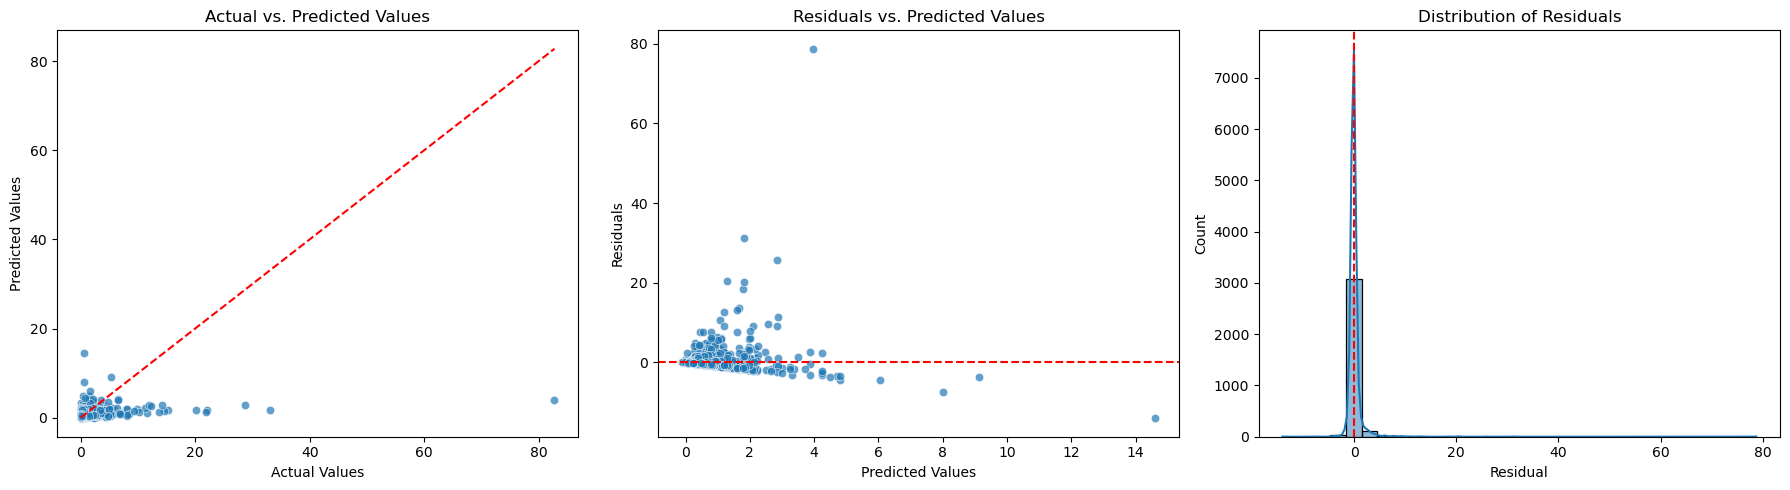

In [43]:
gradient_residuals = y_test - gradient_pred

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Actual versus predicted values
sns.scatterplot(
    x=y_test,
    y=gradient_pred,
    ax=axes[0],
    alpha=0.7
)

axes[0].plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color="red",
    linestyle="--"
)

axes[0].set_title("Actual vs. Predicted Values")
axes[0].set_xlabel("Actual Values")
axes[0].set_ylabel("Predicted Values")

# Residuals versus predictions
sns.scatterplot(
    x=gradient_pred,
    y=gradient_residuals,
    ax=axes[1],
    alpha=0.7
)

axes[1].axhline(
    y=0,
    color="red",
    linestyle="--"
)

axes[1].set_title("Residuals vs. Predicted Values")
axes[1].set_xlabel("Predicted Values")
axes[1].set_ylabel("Residuals")

# Residual distribution
sns.histplot(
    gradient_residuals,
    bins=30,
    kde=True,
    ax=axes[2]
)

axes[2].axvline(
    x=0,
    color="red",
    linestyle="--"
)

axes[2].set_title("Distribution of Residuals")
axes[2].set_xlabel("Residual")

plt.tight_layout()
plt.show()

## Residual Analysis Findings and Target Transformation

The residual diagnostics revealed that the optimized Gradient Boosting model struggled to predict games with exceptionally high sales.

In the actual-versus-predicted plot, most predictions were concentrated near the lower end of the target range. Several high-sales games appeared far below the diagonal reference line, indicating substantial underprediction. For example, an observation with actual sales near 83 was predicted at approximately 4.

The residual-versus-predicted plot also displayed several extremely large positive residuals. Because a positive residual occurs when the actual value exceeds the predicted value, these observations confirm that the model systematically underestimated several commercially successful games.

The residual distribution was sharply concentrated near zero but contained a long right tail. This indicates that the model predicted most lower-sales games with relatively small errors while producing a limited number of extremely large errors. These large errors explain why the model’s RMSE was substantially higher than its MAE.

Because the high-sales observations may represent legitimate blockbuster games rather than data errors, they will not be removed automatically. Instead, a logarithmic target transformation will be evaluated.

A `log1p` transformation reduces the influence of extreme target values while retaining every observation. `TransformedTargetRegressor` will apply the transformation during model training and automatically convert predictions back to the original sales scale using `expm1`.

The log-transformed Gradient Boosting model will be tuned with five-fold cross-validation and compared with the original optimized model to determine whether the transformation improves generalization.


In [44]:
from sklearn.compose import TransformedTargetRegressor

log_gradient_boosting = TransformedTargetRegressor(
    regressor=GradientBoostingRegressor(random_state=42),
    func=np.log1p,
    inverse_func=np.expm1
)

log_gradient_param_grid = {
    "regressor__n_estimators": [100, 200, 300],
    "regressor__learning_rate": [0.03, 0.05, 0.1],
    "regressor__max_depth": [2, 3, 4],
    "regressor__min_samples_leaf": [1, 3]
}

log_gradient_grid = GridSearchCV(
    estimator=log_gradient_boosting,
    param_grid=log_gradient_param_grid,
    scoring="neg_root_mean_squared_error",
    cv=kf,
    n_jobs=-1
)

log_gradient_grid.fit(X_train_processed, y_train)

print("Best parameters:", log_gradient_grid.best_params_)
print("Best CV RMSE:", -log_gradient_grid.best_score_)

Best parameters: {'regressor__learning_rate': 0.1, 'regressor__max_depth': 4, 'regressor__min_samples_leaf': 3, 'regressor__n_estimators': 300}
Best CV RMSE: 1.274606108596793


### Log-Transformed Gradient Boosting with Hyperparameter Tuning

Because the target variable is highly right-skewed and contains large values that are difficult for the model to predict accurately, a **log transformation** was applied to the target using `TransformedTargetRegressor`.

The `log1p` transformation compresses large target values during model training, while `expm1` automatically converts predictions back to the original scale.

To optimize the Gradient Boosting model, **GridSearchCV** was used to evaluate combinations of:

- Number of estimators
- Learning rate
- Maximum tree depth
- Minimum samples per leaf

Cross-validation identified the following optimal hyperparameters:

- **Learning Rate:** 0.10
- **Maximum Depth:** 4
- **Minimum Samples per Leaf:** 3
- **Number of Estimators:** 300

The best cross-validation **RMSE was approximately 1.275**.

The optimized log-transformed model will next be evaluated on the unseen test set and compared with the previous models using **MAE, RMSE, and R²**.

In [45]:
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

# Best model from GridSearchCV
best_log_gradient = log_gradient_grid.best_estimator_

# Predictions on test data
y_pred_log_gradient = best_log_gradient.predict(X_test_processed)

# Evaluation metrics
mse_log_gradient = mean_squared_error(y_test, y_pred_log_gradient)
rmse_log_gradient = np.sqrt(mse_log_gradient)
r2_log_gradient = r2_score(y_test, y_pred_log_gradient)

print("Log-Transformed Gradient Boosting Results")
print(f"MSE:  {mse_log_gradient:.4f}")
print(f"RMSE: {rmse_log_gradient:.4f}")
print(f"R²:   {r2_log_gradient:.4f}")


Log-Transformed Gradient Boosting Results
MSE:  4.0106
RMSE: 2.0026
R²:   0.0625


In [46]:
### Evaluation of the Tuned Log-Transformed Gradient Boosting Model

The optimized log-transformed Gradient Boosting model was evaluated on the unseen test set using MSE, RMSE, and R².

The model produced the following results:

- **MSE:** 4.0106
- **RMSE:** 2.0026
- **R²:** 0.0625

Despite applying a log transformation to reduce the influence of extreme target values and tuning the model's hyperparameters using cross-validation, the model did not improve upon the previous Gradient Boosting model.

The R² value of approximately **0.063** indicates that the model explains only about **6.3% of the variation in the target variable**. This suggests that the limited predictive performance may not be primarily a model-tuning issue. Instead, the existing predictor variables may contain limited information for explaining the variation in the target.

Therefore, further improvements should focus on investigating **feature importance, feature relationships, and potential feature engineering** rather than continuing to tune the same model.

SyntaxError: invalid character '²' (U+00B2) (1999075504.py, line 3)

### Extracting Feature Names and Feature Importances

After preprocessing, the original categorical variables were expanded through one-hot encoding, resulting in **476 processed features**. Before calculating feature importance, the number of generated feature names was compared with the number of columns in the processed training data.

Both values were **476**, confirming that each processed feature could be correctly matched with its corresponding feature name.

The best-performing tuned log-transformed Gradient Boosting model was then retrieved from `GridSearchCV`. Because the Gradient Boosting regressor is nested inside a `TransformedTargetRegressor`, the fitted underlying regressor was accessed to obtain its `feature_importances_`.

The resulting feature importance table ranks the processed variables according to their contribution to the model's predictions. This analysis helps identify which predictors provide the strongest signal and whether the model is relying heavily on only a small subset of the available features.

In [48]:
feature_names = preprocessor.get_feature_names_out()

print("Number of processed features:", X_train_processed.shape[1])
print("Number of feature names:", len(feature_names))

Number of processed features: 476
Number of feature names: 476


In [50]:
best_log_gradient = log_gradient_grid.best_estimator_

feature_importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance": best_log_gradient.regressor_.feature_importances_
}).sort_values(
    by="Importance",
    ascending=False
)

feature_importance.head(15)

,Feature,Importance
128,cat__Publisher_Nintendo,0.206290
475,num__Year,0.170145
80,cat__Publisher_Electronic Arts,0.064309
152,cat__Publisher_Sony Computer Entertainment,0.029858
51,cat__Publisher_Activision,0.024717
167,cat__Publisher_Take-Two Interactive,0.022525
121,cat__Publisher_Microsoft Game Studios,0.021626
35,cat__Genre_Platform,0.021422
17,cat__Platform_PS3,0.020070
32,cat__Genre_Adventure,0.019876


### Aggregating One-Hot Encoded Features Back to Their Original Variables

One-hot encoding expanded the original categorical variables into many individual binary features. As a result, the processed dataset contains **476 features**, even though many of these features represent different categories from the same original variable.

To make the feature importance results easier to interpret, the encoded feature names were mapped back to their original variables.

For example:

- `Publisher_Nintendo` → **Publisher**
- `Publisher_Electronic Arts` → **Publisher**
- `Platform_PS3` → **Platform**
- `Genre_Shooter` → **Genre**
- `Year` → **Year**

This mapping allows the individual importance scores created through one-hot encoding to later be combined, providing a clearer understanding of how much each **original feature** contributes to the model's predictions.

In [51]:
def get_original_feature(feature):
    
    # Remove ColumnTransformer prefixes
    feature = feature.replace("cat__", "").replace("num__", "")
    
    if feature.startswith("Publisher_"):
        return "Publisher"
    
    elif feature.startswith("Platform_"):
        return "Platform"
    
    elif feature.startswith("Genre_"):
        return "Genre"
    
    elif feature == "Year":
        return "Year"
    
    else:
        return feature


feature_importance["Original_Feature"] = (
    feature_importance["Feature"].apply(get_original_feature)
)

feature_importance.head(15)

,Feature,Importance,Original_Feature
128,cat__Publisher_Nintendo,0.206290,Publisher
475,num__Year,0.170145,Year
80,cat__Publisher_Electronic Arts,0.064309,Publisher
152,cat__Publisher_Sony Computer Entertainment,0.029858,Publisher
51,cat__Publisher_Activision,0.024717,Publisher
167,cat__Publisher_Take-Two Interactive,0.022525,Publisher
121,cat__Publisher_Microsoft Game Studios,0.021626,Publisher
35,cat__Genre_Platform,0.021422,Genre
17,cat__Platform_PS3,0.020070,Platform
32,cat__Genre_Adventure,0.019876,Genre


In [52]:
original_feature_importance = (
    feature_importance
    .groupby("Original_Feature", as_index=False)["Importance"]
    .sum()
    .sort_values(
        by="Importance",
        ascending=False
    )
)

original_feature_importance

,Original_Feature,Importance
2,Publisher,0.492663
0,Genre,0.228113
3,Year,0.170145
1,Platform,0.109079


### Aggregated Feature Importance

Because one-hot encoding expanded the categorical variables into hundreds of binary columns, the individual feature importance scores were aggregated back to their original variables. This provides a clearer interpretation of which underlying features contribute most to the Gradient Boosting model.

The aggregated feature importance results were:

- **Publisher:** 49.3%
- **Genre:** 22.8%
- **Year:** 17.0%
- **Platform:** 10.9%

Although preprocessing produced **476 model features**, these columns originate from only four underlying predictor variables. Publisher accounts for nearly half of the model's total feature importance, followed by Genre, Year, and Platform.

Combined with the model's low R², these findings suggest that model performance may be constrained by the limited predictive information available in the original dataset rather than simply by the choice of algorithm or hyperparameters. Additional variables such as review scores, marketing information, pricing, franchise popularity, or other game-specific characteristics could potentially provide additional predictive signal.

Feature importance represents how strongly the fitted Gradient Boosting model relied on each variable and should not be interpreted as evidence of a causal relationship with sales.

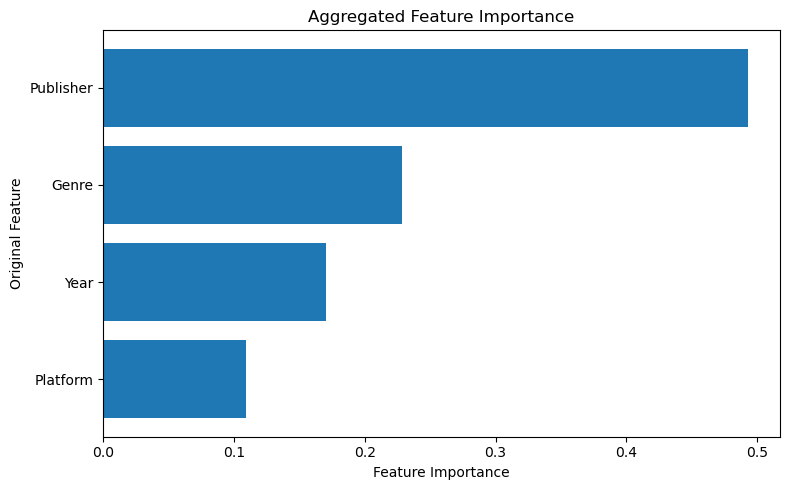

In [53]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.barh(
    original_feature_importance["Original_Feature"],
    original_feature_importance["Importance"]
)

plt.xlabel("Feature Importance")
plt.ylabel("Original Feature")
plt.title("Aggregated Feature Importance")

plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()

### Visualization of Aggregated Feature Importance

To better understand which original variables contribute most to the model's predictions, the feature importance scores from the one-hot encoded variables were aggregated and visualized.

Although preprocessing expanded the dataset to 476 features, these features originate from only four original predictors: **Publisher, Genre, Year, and Platform**.

The visualization provides a clearer view of how the Gradient Boosting model distributes its predictive importance across these underlying variables.

### Interpretation

The feature importance analysis shows that **Publisher is the dominant predictor**, accounting for approximately 49% of the model's total feature importance. Genre contributes approximately 23%, followed by Year at 17% and Platform at 11%.

This concentration of importance, combined with the consistently low R² values obtained across multiple modeling approaches, suggests that the dataset contains limited information for accurately predicting video game sales.

Although one-hot encoding increased the number of model inputs to 476, it did not create new underlying information. The model is still attempting to predict sales using only four original predictor variables.

Therefore, further improvements in predictive performance may depend more on obtaining additional informative features than on additional hyperparameter tuning. Potential predictors could include critic and user review scores, pricing, marketing expenditure, franchise information, release timing, and other game-specific or market-level characteristics.

These feature importance values describe how the fitted Gradient Boosting model used the available predictors and should not be interpreted as causal effects.

## Machine Learning Modeling Conclusion

Multiple regression approaches were evaluated to determine whether video game sales could be accurately predicted using the available features. The modeling process included baseline models, ensemble methods, hyperparameter tuning, residual analysis, and a log transformation of the target variable.

### Model Performance

Despite testing increasingly sophisticated modeling approaches, predictive performance remained relatively weak. The optimized log-transformed Gradient Boosting model produced:

- **MSE:** 4.0106
- **RMSE:** 2.0026
- **R²:** 0.0625

The low R² indicates that the model explains only approximately **6.3% of the variation in video game sales** on the test data.

Importantly, additional hyperparameter tuning and transformation of the target variable did not produce meaningful improvements in generalization performance. This suggests that model complexity alone is unlikely to resolve the prediction problem.

### Feature Importance Findings

Feature importance analysis provided additional insight into the model's limitations. Although one-hot encoding expanded the training data to **476 features**, these features originated from only four underlying predictors:

- **Publisher:** 49.3%
- **Genre:** 22.8%
- **Year:** 17.0%
- **Platform:** 10.9%

Publisher accounted for nearly half of the model's total feature importance, indicating that the model relied heavily on publisher information when making predictions.

However, feature importance represents how the fitted model uses the available predictors and should not be interpreted as evidence of a causal relationship with sales.

### Key Finding

The results suggest that the primary limitation is not necessarily the choice of machine learning algorithm, but the **limited predictive information contained in the available features**.

Video game sales are likely influenced by additional factors that are not represented in the dataset, such as:

- Critic and user review scores
- Marketing expenditure
- Game price
- Franchise popularity
- Release timing
- Competition at the time of release
- Digital versus physical distribution
- Preorders and promotional activity
- Broader market conditions

One-hot encoding increased the dimensionality of the dataset, but it did not introduce new underlying information. Therefore, additional model complexity cannot fully compensate for missing predictive variables.

### Final Conclusion

The modeling process demonstrates that successful machine learning depends not only on selecting and tuning algorithms, but also on the **quality and predictive relevance of the available data**.

Rather than continuing to optimize models against a dataset with limited signal, the most appropriate next step would be to collect or integrate additional explanatory variables that are more directly related to video game sales.

Therefore, the current models should be viewed primarily as exploratory predictive models rather than systems suitable for high-accuracy sales forecasting.